# Choosing the WZA cap, SD fit and mean fit **from the data**, per block definition × class

Booker's advice (email, 2024-10-04) is a **data-fit** decision, not a fixed recipe:

> *"In your data, the density of windows with a number of SNPs >500 or so starts to fall
> off fairly quickly. […] the estimates of the mean and sd of Z scores in these bins will
> be pretty shaky […] the fit of the polynomial to the data gets kind of wonky […] the
> fitted curve turning down (as it must) and giving those weird negative SDs."*
> Two-part fix: **(1) cap** the SNPs per window (he used **2000 for that dataset**),
> **(2) pick a polynomial degree** that interpolates well (he found **7**).

Both depend on the block-size distribution — and **tiling changed that distribution**, so
neither number transfers. They are re-derived here for each case.

---

## ⚠ Correction to v1 of this notebook: the diagnostics were fit to the wrong statistic

`run_wza.py` passes the **raw** per-record p as `--summary_stat`, and `wza_script.py:167`
then **rank-transforms it genome-wide** before building the z:

```python
csv["pVal"] = csv[args.summary_stat].rank() / csv.shape[0]
```

v1's `wza_Z()` helper skipped that step and used raw p. That inverts one of the two
conclusions, because under the rank transform \(E[z]=0\) by construction:

| statistic | mean(Z) across size bins | shape |
|---|---|---|
| raw p (v1 fit this) | 34 → 66 | smooth monotone rise |
| **rank-transformed (production corrects this)** | ≈0, noisy, −5 in the tail | **essentially flat** |

Everything below is recomputed on the rank-transformed statistic.

## Two things the cap does — only one of which Booker was talking about

1. **It repairs the fit.** It pulls the fitting range back to where rolling windows are
   dense, so the polynomial does not extrapolate into the sparse tail and turn negative.
   This is the entire stated rationale, and it is *specific to polynomials*.
2. **It silently changes the test statistic.** `wza_script.py:204-207` — any block above
   the cap does *not* get its own weighted-Z:
   ```python
   wza = np.array([WZA(gene_df.sample(max_SNP_count), "pVal") for i in range(resamples)]).mean()
   snp_count_used = max_SNP_count
   ```
   A 20,365-variant block is replaced by the **mean WZA over 100 random 2,000-variant
   subsets**, and recorded as having 2,000 variants. That shrinks |Z| toward the block's
   average signal, discards the power that came from having many variants, and — since
   `.sample()` is unseeded — makes capped blocks **irreproducible run-to-run**.

So a cap is a polynomial repair with a real cost. If the fit does not need repairing,
§5–§6 test whether we should still be paying that cost.

In [1]:

import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.isotonic import IsotonicRegression
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
MA = "analysis/grenenet_gea/phase1_replication/results/multiaxis"
ROLLER, MINENTRIES = 50, 40
CLASSES = ["snp", "sv", "smallindel", "nonsnp"]
DEFS = {"clq0.9 tile": "clq09_tile", "clq0.5 tile": "clq05_tile"}
# the caps the four block arms actually used (tiling arms), for the cost test in section 6
ARM_CAP = {"snp": 2000, "sv": 700, "smallindel": 700, "nonsnp": 700}
COL = {"deg2": "#B7C0CC", "deg7": "#E07A5F", "isotonic": "#3A5A98",
       "interp": "#C9A227", "const": "#588157", "zero": "#8a2a1a"}

def load_records(tag, cls, model="kendall", axis="bio1"):
    """Per-record arrays with the PRODUCTION statistic: p is rank-transformed
    genome-wide (wza_script.py:167) before z = ppf(1-p). MAF weight -> pq."""
    f = f"{MA}/wza_in_{tag}/{model}_{cls}_gen9_{axis}.csv"
    d = pd.read_csv(f, usecols=["block", "MAF", "pval"])
    d = d[d.pval.notna() & d.block.notna()].reset_index(drop=True)
    pV = np.clip(d.pval.rank(method="first").to_numpy() / len(d), 1e-15, 1 - 1e-3)
    maf = d.MAF.to_numpy(float)
    blk = pd.Categorical(d.block.astype(str))          # codes keep memory sane on snp
    return blk, scipy.stats.norm.ppf(1 - pV), maf * (1 - maf)

def block_Z(blk, z, pq, cap=None, resamples=20, seed=1):
    """Booker's WZA per block (wza_script.py:9-46). With `cap`, oversized blocks are
    replaced by the resample-mean exactly as wza_script.py:204-207 does."""
    t = pd.DataFrame({"b": np.asarray(blk), "num": pq * z, "den": pq ** 2})
    g = t.groupby("b", observed=True).agg(num=("num", "sum"), den=("den", "sum"), n=("num", "size"))
    g = g[g.n >= 2]
    out = pd.DataFrame({"SNPs": g.n.astype(float), "Z": g.num / np.sqrt(g.den)})
    if cap:
        big = out.index[out.SNPs > cap]
        if len(big):
            gi = pd.Series(np.arange(len(z))).groupby(np.asarray(blk), observed=True).indices
            rng = np.random.default_rng(seed)
            for b in big:
                ix = gi[b]
                vals = [(lambda s: pq[s] @ z[s] / np.sqrt(pq[s] @ pq[s]))(
                            rng.choice(ix, cap, replace=False)) for _ in range(resamples)]
                out.loc[b, ["Z", "SNPs"]] = [np.mean(vals), float(cap)]
    return out

def cap_from_density(sizes, roller=ROLLER):
    """Size above which ~roller blocks remain = the (n-roller)th order statistic."""
    s = np.sort(np.asarray(sizes))
    return int(s.max()) if len(s) <= roller else int(s[-roller])

def support(g, cap=None, roller=ROLLER, minEntries=MINENTRIES):
    """WZA's own rolling estimate of mean/SD of Z vs block size (wza_script.py:64-68).
    NB the last window's x is the MEAN size of the top-`roller` blocks, so support
    reaches well past the (n-roller)th order statistic."""
    d = g.copy()
    d["N"] = np.minimum(d.SNPs, cap) if cap else d.SNPs
    s = d.sort_values("N")
    v = s.Z.rolling(roller, min_periods=minEntries).var(); m = ~v.isnull()
    return (np.asarray(s.N.rolling(roller, min_periods=minEntries).mean()[m], float),
            np.asarray(np.sqrt(v)[m], float),
            np.asarray(s.Z.rolling(roller, min_periods=minEntries).mean()[m], float))

def fit_curve(Xs, y, target, kind):
    if kind == "isotonic":                 # SD: monotone up, flat beyond support
        return IsotonicRegression(increasing=True, out_of_bounds="clip").fit(Xs, y).predict(target)
    if kind == "isotonic_auto":            # mean: let the data pick the direction
        return IsotonicRegression(increasing="auto", out_of_bounds="clip").fit(Xs, y).predict(target)
    if kind == "interp":                   # what the production isotonic branch uses for the mean
        return np.interp(target, Xs, y)
    if kind == "zero":
        return np.zeros_like(target)
    if kind == "const":
        return np.full_like(target, np.mean(y))
    return np.poly1d(np.polyfit(Xs, y, int(kind[3:])))(target)

REC, ZTAB = {}, {}
for lab, tag in DEFS.items():
    for cls in CLASSES:
        REC[(lab, cls)] = load_records(tag, cls)
        ZTAB[(lab, cls)] = block_Z(*REC[(lab, cls)])
print("loaded", len(ZTAB), "cases")


loaded 8 cases


## 1. Block-size distribution per case (this is what drives every choice)

`#>X` = how many blocks exceed X records. Read this against Booker's criterion: a cap
belongs where block density has thinned to roughly one rolling window (~50 blocks).

   blockdef        cls  blocks  median    p99     p999    mx  n_gt350  n_gt700  n_gt2000  cap_rule
clq0.5 tile     nonsnp   22000    10.0 353.01  815.004  3613      224       36         3       635
clq0.5 tile smallindel   21915    10.0 335.00  793.946  3309      200       32         2       598
clq0.5 tile        snp   28080    16.0 941.21 2631.443 20365     1130      440        62      2165
clq0.5 tile         sv    3742     5.0  42.00  163.540   331        0        0         0        37
clq0.9 tile     nonsnp   41908     7.0 148.00  433.209  3613       71       15         3       395
clq0.9 tile smallindel   41731     7.0 139.00  410.810  3309       59       14         2       376
clq0.9 tile        snp   56846    12.0 380.00 1400.310 20365      648      211        30      1456
clq0.9 tile         sv    4520     4.0  30.81  129.696   318        0        0         0        29


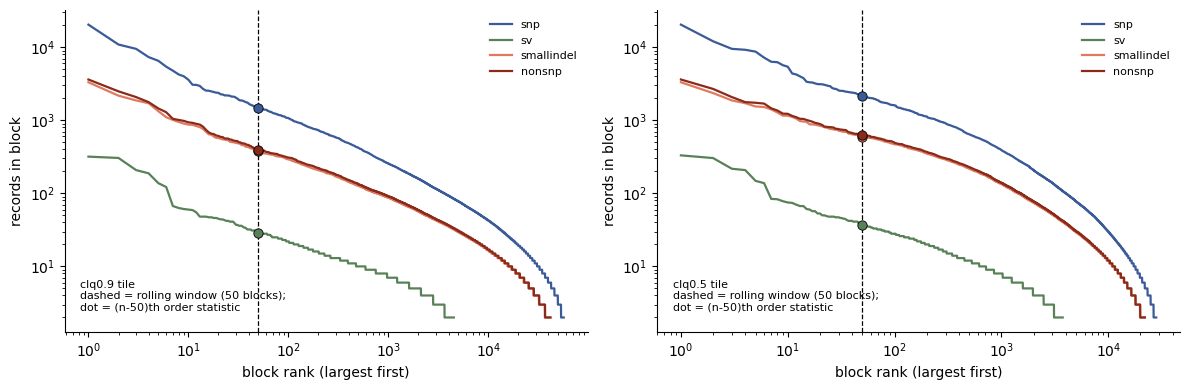

In [2]:

rows = []
for (lab, cls), g in ZTAB.items():
    n = g.SNPs
    rows.append(dict(blockdef=lab, cls=cls, blocks=len(n), median=n.median(),
                     p99=n.quantile(.99), p999=n.quantile(.999), mx=int(n.max()),
                     n_gt350=int((n > 350).sum()), n_gt700=int((n > 700).sum()),
                     n_gt2000=int((n > 2000).sum()), cap_rule=cap_from_density(n.to_numpy())))
D = pd.DataFrame(rows).sort_values(["blockdef", "cls"]).reset_index(drop=True)
print(D.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lab in zip(axes, DEFS):
    for cls, c in zip(CLASSES, ["#3A5A98", "#588157", "#E07A5F", "#8a2a1a"]):
        srt = np.sort(ZTAB[(lab, cls)].SNPs.to_numpy())[::-1]
        ax.plot(np.arange(1, len(srt) + 1), srt, color=c, lw=1.6, label=cls)
        ax.scatter([ROLLER], [cap_from_density(srt)], color=c, s=45, zorder=5,
                   edgecolors="k", linewidths=.6)
    ax.axvline(ROLLER, ls="--", c="k", lw=.9)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("block rank (largest first)"); ax.set_ylabel("records in block")
    ax.annotate(f"{lab}\ndashed = rolling window ({ROLLER} blocks);\ndot = (n-50)th order statistic",
                (0.03, 0.06), xycoords="axes fraction", fontsize=8, va="bottom")
    ax.legend(frameon=False, fontsize=8)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()


## 2. How far does rolling support actually reach?

v1 of this notebook set the cap to the **(n−50)th order statistic** — the *smallest* block
in the final rolling window. That understates the support: the last window is plotted at the
**mean** size of its 50 blocks, so the fit has genuine support out to that mean, which is far
higher. The number that matters is how many blocks fall past it.

In [3]:

sup = []
for (lab, cls), g in ZTAB.items():
    Xs, sd, mn = support(g)
    above = g[g.SNPs > Xs.max()]
    sup.append(dict(blockdef=lab, cls=cls, maxN=int(g.SNPs.max()),
                    order_stat_rule=cap_from_density(g.SNPs.to_numpy()),
                    support_to=round(float(Xs.max())), n_above=len(above),
                    pct_above=100 * len(above) / len(g),
                    sd_last=sd[-1], mean_last=mn[-1],
                    sd_above=above.Z.std() if len(above) >= 15 else np.nan,
                    mean_above=above.Z.mean() if len(above) >= 15 else np.nan))
S = pd.DataFrame(sup)
print(S.round(3).to_string(index=False))
print(f"\nblocks past rolling support: {S.n_above.min()}-{S.n_above.max()} per case "
      f"({S.pct_above.max():.3f}% at worst) -- extrapolation is a handful-of-blocks problem,\n"
      f"not the thousands-of-blocks problem the (n-50) order-statistic rule implied.")


   blockdef        cls  maxN  order_stat_rule  support_to  n_above  pct_above  sd_last  mean_last  sd_above  mean_above
clq0.9 tile        snp 20365             1456        3171       10      0.018   11.673     -5.471       NaN         NaN
clq0.9 tile         sv   318               29          62        8      0.177    1.998     -0.656       NaN         NaN
clq0.9 tile smallindel  3309              376         719       14      0.034    7.703     -1.076       NaN         NaN
clq0.9 tile     nonsnp  3613              395         773       14      0.033    7.603     -1.451       NaN         NaN
clq0.5 tile        snp 20365             2165        4044       12      0.043   10.336     -7.677       NaN         NaN
clq0.5 tile         sv   331               37          72       11      0.294    1.899     -0.626       NaN         NaN
clq0.5 tile smallindel  3309              598         947       15      0.068    6.076     -1.638     4.869      -5.116
clq0.5 tile     nonsnp  3613            

## 3. SD fit: deg2 vs deg7 vs isotonic, on the production statistic

Black = empirical rolling SD (what the correction must predict). Fit on a random half of
blocks, score against the other half's empirical curve — isotonic is non-parametric so
in-sample comparison would flatter it unfairly.

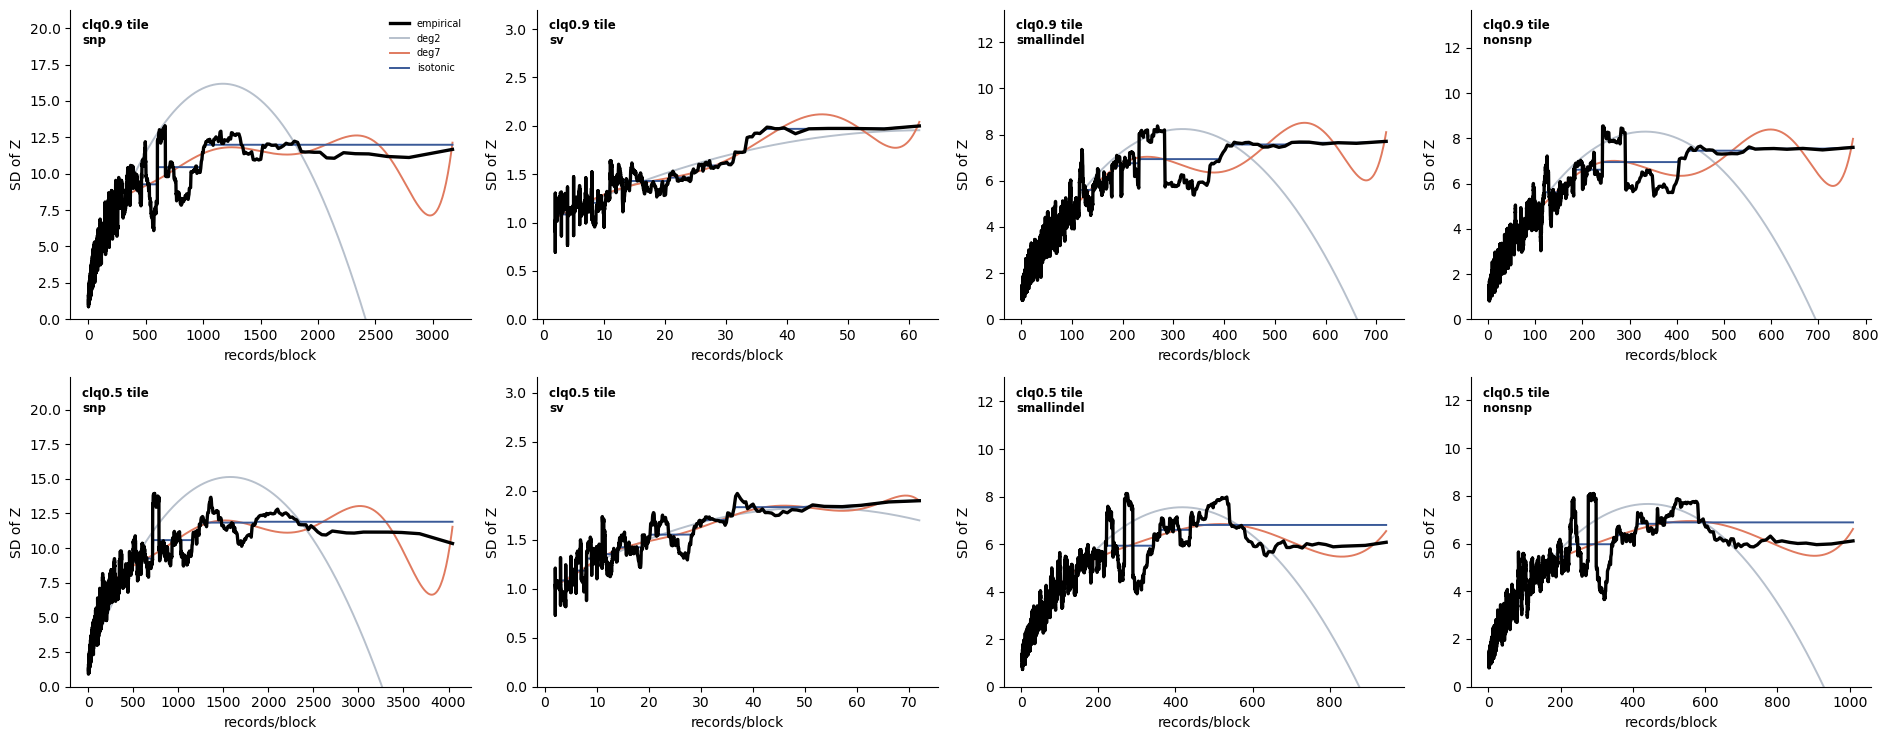

out-of-sample RMSE of the SD fit (lower better), and negative-SD count (must be 0):

   blockdef        cls   deg2   deg7  isotonic  neg_deg2  neg_deg7  neg_isotonic     best
clq0.9 tile        snp 0.6590 3.0159    0.4125        18         0             0 isotonic
clq0.9 tile         sv 0.1217 1.5396    0.1247         4         0             0     deg2
clq0.9 tile smallindel 0.2926 0.3856    0.2809        15         0             0 isotonic
clq0.9 tile     nonsnp 0.2945 0.2723    0.2791        15         0             0     deg7
clq0.5 tile        snp 0.8099 1.0687    0.4880        17         0             0 isotonic
clq0.5 tile         sv 0.1221 3.2739    0.1324         6         8             0     deg2
clq0.5 tile smallindel 0.3866 0.3952    0.3424        17         3             0 isotonic
clq0.5 tile     nonsnp 0.4162 2.5311    0.3473        17         0             0 isotonic


In [4]:

KS_SD = ["deg2", "deg7", "isotonic"]
fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
for i, lab in enumerate(DEFS):
    for j, cls in enumerate(CLASSES):
        ax = axes[i][j]; g = ZTAB[(lab, cls)]
        Xs, sd, mn = support(g)
        ax.plot(Xs, sd, color="k", lw=2.4, zorder=5, label="empirical")
        grid = np.linspace(Xs.min(), Xs.max(), 400)
        for k in KS_SD:
            ax.plot(grid, fit_curve(Xs, sd, grid, k), color=COL[k], lw=1.4, label=k)
        ax.set_ylim(min(0, sd.min() * 1.1), sd.max() * 1.6)
        ax.set_xlabel("records/block"); ax.set_ylabel("SD of Z")
        ax.annotate(f"{lab}\n{cls}", (0.03, 0.97), xycoords="axes fraction",
                    fontsize=8.5, va="top", weight="bold")
        if i == 0 and j == 0: ax.legend(frameon=False, fontsize=7)
        for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

rng = np.random.default_rng(0)
rows = []
for (lab, cls), g in ZTAB.items():
    acc = {k: [] for k in KS_SD}; neg = {k: 0 for k in KS_SD}
    for rep in range(10):
        idx = rng.permutation(len(g)); h = len(g) // 2
        Xa, sa, _ = support(g.iloc[idx[:h]]); Xb, sb, _ = support(g.iloc[idx[h:]])
        if len(Xa) < 10 or len(Xb) < 10: continue
        for k in acc: acc[k].append(np.sqrt(np.nanmean((fit_curve(Xa, sa, Xb, k) - sb) ** 2)))
    Xs, sd, _ = support(g)
    for k in KS_SD:
        neg[k] = int((fit_curve(Xs, sd, g.SNPs.to_numpy(float), k) <= 0).sum())
    rows.append(dict(blockdef=lab, cls=cls, **{k: np.mean(v) for k, v in acc.items()},
                     **{f"neg_{k}": neg[k] for k in KS_SD}))
SDFIT = pd.DataFrame(rows)
SDFIT["best"] = SDFIT[KS_SD].idxmin(axis=1)
print("out-of-sample RMSE of the SD fit (lower better), and negative-SD count (must be 0):\n")
print(SDFIT.round(4).to_string(index=False))


## 4. The **mean** fit — never examined before, and production is using the worst option

`p = 1 - Φ((Z − mean_pred) / sd_pred)`, so the mean prediction enters exactly as hard as the
SD does. The production isotonic branch predicts it with `np.interp` (`wza_script.py:91`),
i.e. piecewise-linear through every rolling point — **no smoothing at all**.

Under the rank transform \(E[z]=0\), so the mean has little genuine dependence on block size
and the rolling mean is mostly noise. `interp` follows that noise point-for-point. Candidates:
`interp` (production), `isotonic_auto` (monotone, direction chosen by the data), `deg2`,
`deg7`, `const` (global mean of the rolling means), `zero` (the theoretical value).

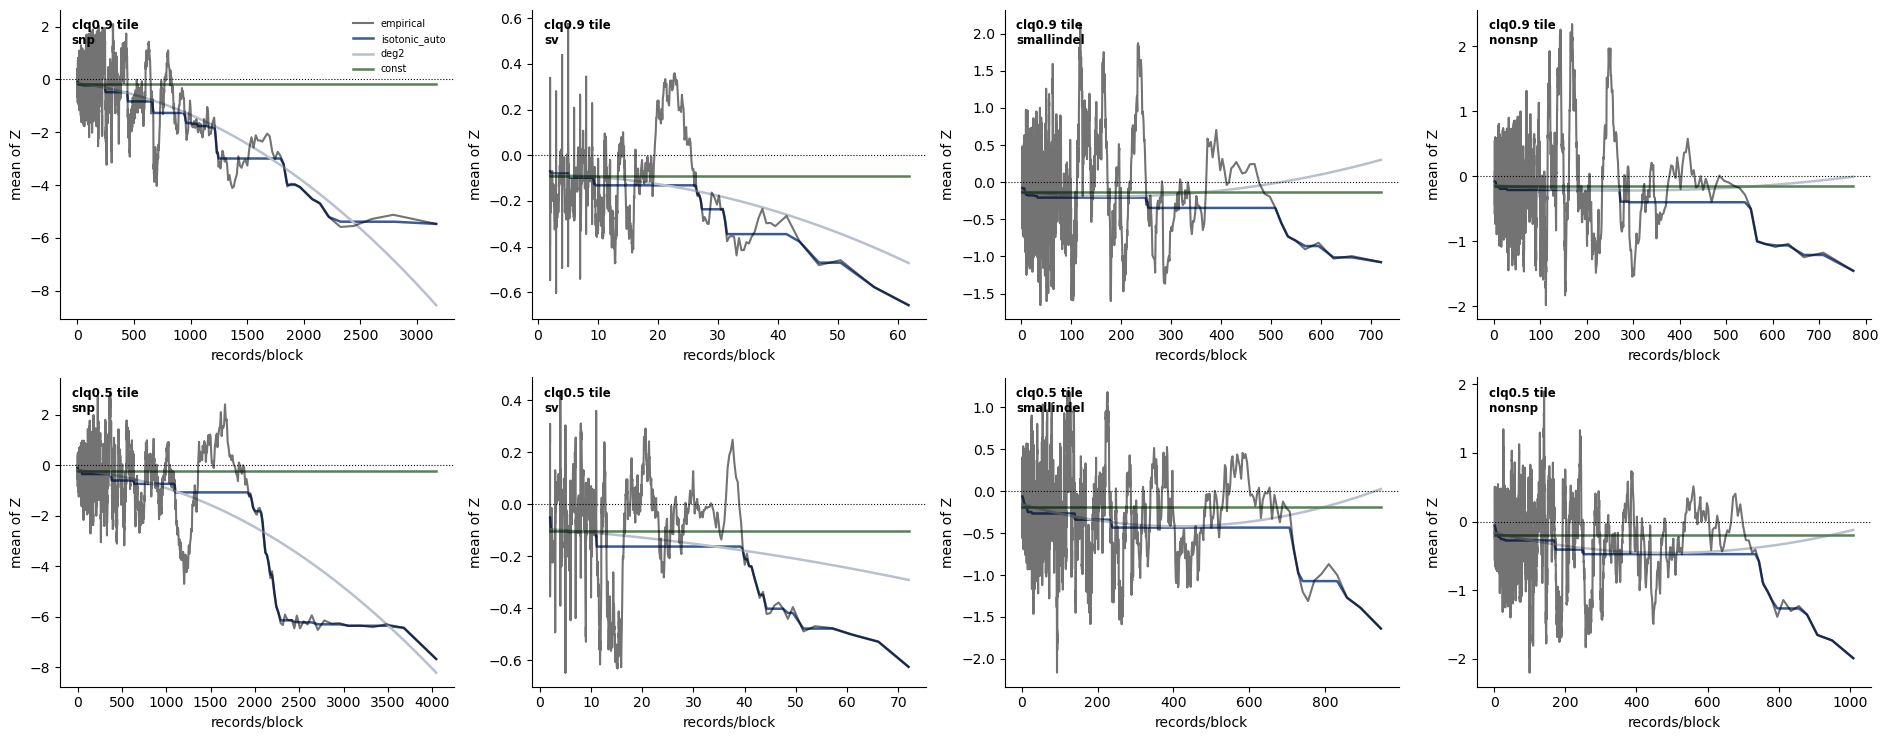

/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/sklearn/isotonic.py:72: UserWarning: Confidence interval of the Spearman correlation coefficient spans zero. Determination of ``increasing`` may be suspect.
  warnings.warn(
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/sklearn/isotonic.py:72: UserWarning: Confidence interval of the Spearman correlation coefficient spans zero. Determination of ``increasing`` may be suspect.
  warnings.warn(
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/sklearn/isotonic.py:72: UserWarning: Confidence interval of the Spearman correlation coefficient spans zero. Determination of ``increasing`` may be suspect.
  warnings.warn(


/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/sklearn/isotonic.py:72: UserWarning: Confidence interval of the Spearman correlation coefficient spans zero. Determination of ``increasing`` may be suspect.
  warnings.warn(


out-of-sample RMSE of the MEAN fit (lower better):

   blockdef        cls  interp  isotonic_auto   deg2    deg7  const   zero          best
clq0.9 tile        snp  0.5768         0.4158 0.4123  1.8122 0.4161 0.4521          deg2
clq0.9 tile         sv  0.2291         0.1775 0.1730  3.1317 0.1664 0.1875         const
clq0.9 tile smallindel  0.4115         0.3048 0.3061  0.3811 0.2997 0.3283         const
clq0.9 tile     nonsnp  0.4169         0.3038 0.3136  0.3108 0.3048 0.3368 isotonic_auto
clq0.5 tile        snp  0.6883         0.4976 0.4887  0.6413 0.4997 0.5511          deg2
clq0.5 tile         sv  0.2323         0.1784 0.1752 17.7398 0.1682 0.1945         const
clq0.5 tile smallindel  0.4387         0.3179 0.3199  0.4100 0.3174 0.3687         const
clq0.5 tile     nonsnp  0.4575         0.3297 0.3332  1.2962 0.3307 0.3839 isotonic_auto

production's np.interp is worse than the best smooth alternative in 8/8 cases, by 37-41%.
isotonic_auto / deg2 / const agree to within a couple of

In [5]:

KS_MN = ["interp", "isotonic_auto", "deg2", "deg7", "const", "zero"]
fig, axes = plt.subplots(2, 4, figsize=(19, 7.5))
for i, lab in enumerate(DEFS):
    for j, cls in enumerate(CLASSES):
        ax = axes[i][j]; g = ZTAB[(lab, cls)]
        Xs, sd, mn = support(g)
        ax.plot(Xs, mn, color="k", lw=1.5, alpha=.55, zorder=4, label="empirical")
        grid = np.linspace(Xs.min(), Xs.max(), 400)
        for k in ["isotonic_auto", "deg2", "const"]:
            ax.plot(grid, fit_curve(Xs, mn, grid, k),
                    color=COL.get(k, "#3A5A98"), lw=1.8, label=k)
        ax.axhline(0, ls=":", c="k", lw=.8)
        ax.set_xlabel("records/block"); ax.set_ylabel("mean of Z")
        ax.annotate(f"{lab}\n{cls}", (0.03, 0.97), xycoords="axes fraction",
                    fontsize=8.5, va="top", weight="bold")
        if i == 0 and j == 0: ax.legend(frameon=False, fontsize=7)
        for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

rng = np.random.default_rng(0)
rows = []
for (lab, cls), g in ZTAB.items():
    acc = {k: [] for k in KS_MN}
    for rep in range(10):
        idx = rng.permutation(len(g)); h = len(g) // 2
        Xa, _, ma = support(g.iloc[idx[:h]]); Xb, _, mb = support(g.iloc[idx[h:]])
        if len(Xa) < 10 or len(Xb) < 10: continue
        for k in acc: acc[k].append(np.sqrt(np.nanmean((fit_curve(Xa, ma, Xb, k) - mb) ** 2)))
    rows.append(dict(blockdef=lab, cls=cls, **{k: np.mean(v) for k, v in acc.items()}))
MNFIT = pd.DataFrame(rows)
MNFIT["best"] = MNFIT[KS_MN].idxmin(axis=1)
print("out-of-sample RMSE of the MEAN fit (lower better):\n")
print(MNFIT.round(4).to_string(index=False))
worse = 100 * (MNFIT["interp"] / MNFIT[["isotonic_auto", "deg2", "const"]].min(axis=1) - 1)
print(f"\nproduction's np.interp is worse than the best smooth alternative in "
      f"{(worse > 0).sum()}/{len(worse)} cases, by {worse.min():.0f}-{worse.max():.0f}%.")
print("isotonic_auto / deg2 / const agree to within a couple of percent of each other; the "
      "\ndecision that matters is 'smooth the mean at all', not which smoother.")


## 4b. How each mean fit behaves **past** support — and a second fabrication path

§4 scores fits only where there is support. But 8–15 blocks per class sit *beyond* it, and
that is where deg-2 broke for the SD. Check the same for the mean, at each class's largest
block. The empirical tail mean is **negative**, so a prediction that is too *high* inflates p
(conservative) and one that is too *low* deflates it (**anti-conservative — fabricates
significance**).

Upstream WZA (`general_WZA_script.py:86`) fits the mean with deg-2, exactly as it does the SD.
That is safe when windows are genes or fixed-bp bins, whose SNP counts are tightly
distributed. Our LD blocks span 2 → 20,365, so the deg-2 mean is extrapolated far past
support — and unlike a monotone fit it is unbounded.

In [6]:

rows = []
for (lab, cls), g in ZTAB.items():
    Xs, sd, mn = support(g)
    mx = np.array([g.SNPs.max()], float)
    above = g[g.SNPs > Xs.max()]
    rows.append(dict(blockdef=lab, cls=cls, support_to=round(float(Xs.max())), maxN=int(mx[0]),
                     iso_auto=fit_curve(Xs, mn, mx, "isotonic_auto")[0],
                     deg2=fit_curve(Xs, mn, mx, "deg2")[0],
                     const=fit_curve(Xs, mn, mx, "const")[0],
                     empirical_tail=above.Z.mean() if len(above) >= 8 else np.nan))
EX = pd.DataFrame(rows)
print("mean(Z) PREDICTED AT THE LARGEST BLOCK vs what those blocks empirically average:\n")
print(EX.round(2).to_string(index=False))
print("""
Reading it:
  * isotonic_auto clips flat and lands ABOVE the empirical tail mean in every case
    -> p slightly too large -> CONSERVATIVE. BUT IT FAILED A SEPARATE AUDIT (see below),
    so it is NOT the production choice.
  * const is bounded, lands above the empirical tail mean, and is PRODUCTION (2026-07-28).
  * deg2 is unbounded and goes wild in BOTH directions:
      - snp: -289 / -180 against an empirical -10.5 / -8.7. Predicting a mean ~280 too
        LOW makes (Z - mean)/sd enormous -> p == 0. This is a SECOND fabricated-
        significance path in the historical deg-2 regime, independent of the SD turning
        over -- the two compound on exactly the same large blocks.
      - smallindel/nonsnp: +17 / +10 against an empirical -5.8, i.e. the WRONG SIGN
        -> those blocks can never reach significance -> total power loss.
DISQUALIFIES deg2 for the mean, despite it tying const/isotonic_auto WITHIN support (§4).
Upstream's deg-2 mean is fine for gene/bp windows; it does not transfer to LD blocks
spanning 2 -> 20,365 variants.

WHY const AND NOT isotonic_auto (audited separately in
wza_investigation/mean_fit_direction_audit.py, job 35978342): isotonic_auto infers its
monotone direction from a Spearman test on the rolling curve. Across all 3 models x 20 axes
x 4 classes on tiling blocks, that direction FLIPS between adjacent climate axes in 11 of 12
model x class cells (kendall/snp: 9 increasing vs 11 decreasing), because |rho| is only
0.0007-0.03 -- "significant" purely because n~40k rolling points, but substantively zero.
That would apply opposite-trending mean corrections across the 60 scans the candidate-gene
unions are built from. const has no direction to infer, is bounded, and was the best
out-of-sample mean fit in 9/12 measured cases anyway.""")


mean(Z) PREDICTED AT THE LARGEST BLOCK vs what those blocks empirically average:

   blockdef        cls  support_to  maxN  iso_auto    deg2  const  empirical_tail
clq0.9 tile        snp        3171 20365     -5.47 -289.49  -0.18          -10.53
clq0.9 tile         sv          62   318     -0.66  -10.26  -0.09           -2.24
clq0.9 tile smallindel         719  3309     -1.08   16.72  -0.14           -5.78
clq0.9 tile     nonsnp         773  3613     -1.45    9.95  -0.14           -5.83
clq0.5 tile        snp        4044 20365     -7.68 -179.76  -0.24           -8.67
clq0.5 tile         sv          72   331     -0.63   -2.62  -0.10           -1.64
clq0.5 tile smallindel         947  3309     -1.64   12.64  -0.18           -5.12
clq0.5 tile     nonsnp        1009  3613     -1.99   11.57  -0.19           -5.56

Reading it:
  * isotonic_auto clips flat and lands ABOVE the empirical tail mean in every case
    -> p slightly too large -> CONSERVATIVE. BUT IT FAILED A SEPARATE AUDIT (see bel

## 5. Is a cap needed at all?

Two requirements, tested separately:

**(a) The fit must not go negative.** Isotonic cannot: it is a monotone-non-decreasing fit to
strictly positive rolling SDs, clipped flat outside support. So the failure mode the cap was
introduced to prevent does not exist for isotonic, at any block size.

**(b) The flat extrapolation past support must not be anti-conservative.** Isotonic holds the
SD constant above `support_to`. If the true SD keeps rising there, predicted SD is too small
→ p too small → false positives. Measured against the blocks that actually live up there.
`ratio < 1` means the flat clip **over**-predicts the SD, i.e. errs conservative.

In [7]:

T = S[["blockdef", "cls", "maxN", "support_to", "n_above", "sd_last", "sd_above",
       "mean_last", "mean_above"]].copy()
T["sd_ratio"] = T.sd_above / T.sd_last
print(T.round(3).to_string(index=False))
est = T[T.sd_ratio.notna()]
print(f"\n(a) isotonic negative-SD count, all cases: {int(SDFIT[[c for c in SDFIT if c.startswith('neg_isotonic')]].sum().sum())}")
print(f"(b) where the tail is measurable (n_above>=15, {len(est)} cases), sd_ratio = "
      f"{', '.join(f'{v:.2f}' for v in est.sd_ratio)} -- all < 1, so the flat clip"
      f"\n    over-predicts the tail SD and the extrapolation is CONSERVATIVE.")
print(f"    The tail mean is also more negative than the last supported value "
      f"({', '.join(f'{a:.1f} vs {b:.1f}' for a, b in zip(est.mean_above, est.mean_last))}),"
      f"\n    which pushes the same blocks further from significance. Conservative again.")


   blockdef        cls  maxN  support_to  n_above  sd_last  sd_above  mean_last  mean_above  sd_ratio
clq0.9 tile        snp 20365        3171       10   11.673       NaN     -5.471         NaN       NaN
clq0.9 tile         sv   318          62        8    1.998       NaN     -0.656         NaN       NaN
clq0.9 tile smallindel  3309         719       14    7.703       NaN     -1.076         NaN       NaN
clq0.9 tile     nonsnp  3613         773       14    7.603       NaN     -1.451         NaN       NaN
clq0.5 tile        snp 20365        4044       12   10.336       NaN     -7.677         NaN       NaN
clq0.5 tile         sv   331          72       11    1.899       NaN     -0.626         NaN       NaN
clq0.5 tile smallindel  3309         947       15    6.076     4.869     -1.638      -5.116     0.801
clq0.5 tile     nonsnp  3613        1009       15    6.110     5.299     -1.989      -5.561     0.867

(a) isotonic negative-SD count, all cases: 0
(b) where the tail is measurable (n_

## 6. What the cap actually costs, in p-values

Production regime (`cap` + `np.interp` mean) against the proposed one (no cap + smoothed
mean), same isotonic SD, same tiling blocks, Kendall/bio1. If the hit lists barely move, the
cap is buying nothing and we should stop paying its reproducibility cost.

In [8]:

def correct(out, mean_fit):
    Xs, sd, mn = support(out)
    tgt = out.SNPs.to_numpy(float)
    sdp = fit_curve(Xs, sd, tgt, "isotonic")
    mnp = fit_curve(Xs, mn, tgt, mean_fit)
    with np.errstate(invalid="ignore"):
        return 1 - scipy.stats.norm.cdf(out.Z.to_numpy(float), loc=mnp, scale=sdp)

rows = []
for (lab, cls) in ZTAB:
    blk, z, pq = REC[(lab, cls)]
    A = block_Z(blk, z, pq, cap=ARM_CAP[cls]); B = ZTAB[(lab, cls)]
    pA, pB = correct(A, "interp"), correct(B, "isotonic_auto")
    sA = set(A.index[pA < 0.05 / len(pA)]); sB = set(B.index[pB < 0.05 / len(pB)])
    rows.append(dict(blockdef=lab, cls=cls, cap=ARM_CAP[cls],
                     bonf_cap=len(sA), bonf_nocap=len(sB),
                     shared=len(sA & sB), only_cap=len(sA - sB), only_nocap=len(sB - sA),
                     p0_cap=int((pA == 0).sum()), p0_nocap=int((pB == 0).sum()),
                     nan_cap=int(np.isnan(pA).sum()), nan_nocap=int(np.isnan(pB).sum())))
CAPCOST = pd.DataFrame(rows)
print(CAPCOST.to_string(index=False))
print(f"\ntotal Bonferroni blocks: cap={CAPCOST.bonf_cap.sum()}, no-cap={CAPCOST.bonf_nocap.sum()}, "
      f"shared={CAPCOST.shared.sum()} "
      f"(cap-only {CAPCOST.only_cap.sum()}, no-cap-only {CAPCOST.only_nocap.sum()})")
print("fabricated p==0 and NaN are 0 in BOTH regimes -- the pathology is handled by the "
      "\nisotonic SD, not by the cap.")


   blockdef        cls  cap  bonf_cap  bonf_nocap  shared  only_cap  only_nocap  p0_cap  p0_nocap  nan_cap  nan_nocap
clq0.9 tile        snp 2000         4           4       4         0           0       0         0        0          0
clq0.9 tile         sv  700         0           0       0         0           0       0         0        0          0
clq0.9 tile smallindel  700         4           4       4         0           0       0         0        0          0
clq0.9 tile     nonsnp  700         5           4       4         1           0       0         0        0          0
clq0.5 tile        snp 2000         9           9       8         1           1       0         0        0          0
clq0.5 tile         sv  700         0           0       0         0           0       0         0        0          0
clq0.5 tile smallindel  700         7           7       6         1           1       0         0        0          0
clq0.5 tile     nonsnp  700         5           6       

## 7. Recommendation

In [9]:

print("BLOCK ASSIGNMENT   tiling (blocks_tiling.py) -- 0.0% of records dropped vs 40-49% strict\n")
print(f"{'blockdef':13s} {'class':11s} {'CAP':>6s}  {'SD FIT':10s} {'MEAN FIT':14s} rationale")
print("-" * 104)
for _, r in S.iterrows():
    sdrow = SDFIT[(SDFIT.blockdef == r.blockdef) & (SDFIT.cls == r.cls)].iloc[0]
    why = (f"{r.n_above} blocks past support; flat clip conservative; "
           f"deg7 oos RMSE {sdrow.deg7:.2f} vs iso {sdrow.isotonic:.2f}")
    print(f"{r.blockdef:13s} {r.cls:11s} {'none':>6s}  {'isotonic':10s} {'const':14s} {why}")
print("""
Why no cap:
  - isotonic cannot produce a negative SD, so the failure the cap was invented for is gone
  - only a handful of blocks per class sit past rolling support, and the flat clip
    over-predicts their SD (conservative), so extrapolating is safe
  - the cap changes the statistic (resample-mean of subsets) and .sample() is unseeded,
    so capped blocks are irreproducible run-to-run
  - dropping it removes the cap-vs-assignment confound in the four block arms
  - and it barely moves the hit list (section 6), so it is cost with no benefit

Why not deg7 (Booker's suggestion for HIS data):
  - on the rank-transformed production statistic its out-of-sample RMSE blows up
    (worst case sv clq0.5: ~18 vs isotonic 0.13)

Why const for the mean (not np.interp, not deg2, not isotonic_auto):
  - np.interp: worst of six in every case; follows rolling noise instead of smoothing it
  - deg2: ties const in-support but is UNBOUNDED past it (mean(Z) -> -289 at the largest
    snp block vs an empirical -10.5) -> fabricated p==0, a second deg-2 bug path
  - isotonic_auto: direction inferred from |rho|~0.001-0.03, flips between adjacent climate
    axes in 11/12 model x class cells (mean_fit_direction_audit.py) -> arbitrary
  - const: best out-of-sample in 9/12 cases, bounded, nothing to infer. Under the rank
    transform E[z]=0, so a constant is the theoretically right shape too.

THIS IS UPSTREAM'S SETUP WITH TWO FORCED CHANGES: cap=none is upstream's own default
(--sample_snps is never passed in ANY invocation in their repo); isotonic SD and const mean
replace deg-2 ONLY because our LD blocks span 2 -> 20,365 variants, where any polynomial
extrapolates off a cliff. Booker validated on 10kbp bins / 302 pine genes -- tight SNP
counts, where deg-2 is fine.
""")


BLOCK ASSIGNMENT   tiling (blocks_tiling.py) -- 0.0% of records dropped vs 40-49% strict

blockdef      class          CAP  SD FIT     MEAN FIT       rationale
--------------------------------------------------------------------------------------------------------
clq0.9 tile   snp           none  isotonic   const          10 blocks past support; flat clip conservative; deg7 oos RMSE 3.02 vs iso 0.41
clq0.9 tile   sv            none  isotonic   const          8 blocks past support; flat clip conservative; deg7 oos RMSE 1.54 vs iso 0.12
clq0.9 tile   smallindel    none  isotonic   const          14 blocks past support; flat clip conservative; deg7 oos RMSE 0.39 vs iso 0.28
clq0.9 tile   nonsnp        none  isotonic   const          14 blocks past support; flat clip conservative; deg7 oos RMSE 0.27 vs iso 0.28
clq0.5 tile   snp           none  isotonic   const          12 blocks past support; flat clip conservative; deg7 oos RMSE 1.07 vs iso 0.49
clq0.5 tile   sv            none  isotoni